In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
from fredapi import Fred
from sklearn.covariance import LedoitWolf,OAS
import warnings
from rich.console import Console
from rich.panel import Panel
from tqdm import tqdm


warnings.filterwarnings("ignore")
df = pd.read_csv("ML csv/data.csv", sep=";", decimal=",")
df = df.rename(columns={"Column1": "Date","Column2": "BENCH",})
df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")

In [126]:
#return a df of size (lookback, number of sectors) with log returns
def GetReturn(df,date,lookback):
    date=pd.to_datetime(date)
    if date not in df["Date"].values:#add breaker if windows not in df
        raise ValueError("Date not in dataframe")
    returns_df=df.copy()
    returns_df=returns_df.drop(columns=["BENCH"])

    date_index = returns_df.index[returns_df["Date"] == date][0]
    returns_df=returns_df[(returns_df.index<=date_index) & (returns_df.index>=date_index-lookback) ]
    returns_df.drop(columns="Date",inplace=True)

    returns_df = np.log(returns_df/ returns_df.shift(1))
    returns_df.dropna(inplace=True)
    #print(returns_df.std().mean()) #verification if std is around 1% daily

    return returns_df

#return a df of size (lookback, 1) with log returns of SPX
def GetReturnSPX(df,date,lookback):
    date=pd.to_datetime(date)
    if date not in df["Date"].values:#add breaker if windows not in df
        raise ValueError("Date not in dataframe")
    returns_df = df[["Date","BENCH"]].copy()
    date_index = returns_df.index[returns_df["Date"] == date][0]

    returns_df=returns_df[(returns_df.index<=date_index) & (returns_df.index>=date_index-lookback) ]
    returns_df.drop(columns="Date",inplace=True)
    returns_df = np.log(returns_df/ returns_df.shift(1))
    returns_df.dropna(inplace=True)
    #print(returns_df.std().mean()) #verification if std is around 1% daily

    return returns_df


In [127]:
#return a cov matrix of size (number of sectors, number of sectors) we use lookback to have different window sizes
def GetSigma(df,date,lookback):
    returns_df=GetReturn(df,date,lookback=lookback)
    #covariance matric from returns_df
    sigma_windowed=returns_df.cov()

    return sigma_windowed

#return the n by n variance covariance matrix by ledoitwolf
def get_shrunk_covariance(df,date,lookback):
    returns=GetReturn(df,date,lookback)

    lw = OAS()
    lw.fit(returns)
    shrunk_cov = lw.covariance_
    if isinstance(returns, pd.DataFrame):
        shrunk_cov = pd.DataFrame(shrunk_cov,index=returns.columns,columns=returns.columns)

    return shrunk_cov


#can be used if we want to ban specifics periods from our backtesting
def getSigmaModified(df,date,lookback,listofbanneddays,periodison=False):
    date=pd.to_datetime(date)
    if date not in df["Date"].values:#add breaker if windows not in df
        raise ValueError("Date not in dataframe")

    returns_df=df.copy()
    returns_df=returns_df.drop(columns=["BENCH"])

    date_index = returns_df.index[returns_df["Date"] == date][0]
    returns_df=returns_df[(returns_df.index<=date_index) & (returns_df.index>=date_index-lookback)]
    #days selection

    #banned days
    for banned_date in listofbanneddays:
        mask = returns_df["Date"] == banned_date
        if mask.any():
            print("got one :", banned_date)
            returns_df.loc[mask, :] = np.nan

    returns_df.drop(columns="Date",inplace=True)
    returns_df.dropna(inplace=True)

    #calculation of returns
    returns_df = np.log(returns_df/ returns_df.shift(1))
    returns_df.dropna(inplace=True)

    #covaraicne matrix using shrinkage
    lw = OAS()
    lw.fit(returns_df)
    shrunk_cov = lw.covariance_

    if isinstance(returns_df, pd.DataFrame):
        shrunk_cov = pd.DataFrame(
            shrunk_cov,
            index=returns_df.columns,
            columns=returns_df.columns
        )


    return shrunk_cov

In [128]:
#compute risk free dataframe using API from FRED and get the cumulative risk free rate in a df
def GetRfDataframe(df):
    fred = Fred(api_key="5c742a53d96bd3085e9199dcdb5af60b")
    riskfree = fred.get_series('DFF')
    #riskfree = fred.get_series('DTB1MO') #other data source to compute rf

    riskfree = riskfree.to_frame(name='FedFunds')
    riskfree.index.name = "Date"
    riskfree = riskfree[riskfree.index >= "2000-01-01"]
    riskfree["FedFunds"]=riskfree["FedFunds"]/100
    list_days_open = pd.to_datetime(df["Date"], dayfirst=True, errors="coerce")
    list_days_full = pd.to_datetime(riskfree.index, dayfirst=True, errors="coerce")

    list_days_open=[pd.to_datetime(date) for date in list_days_open]
    list_days_full=[pd.to_datetime(date) for date in list_days_full]


    list_days_open_pondered=[]
    riskfree_list=[]
    count_list=[]
    timestamp=0
    while timestamp < len(list_days_full)-1:

      if list_days_full[timestamp+1] in list_days_open:
            list_days_open_pondered.append(list_days_full[timestamp])
            riskfree_list.append(riskfree["FedFunds"].loc[list_days_full[timestamp]])
            count_list.append(1)
            timestamp += 1

      else:
          count = 0
          timestampbis = timestamp
          while (timestamp + 1 < len(list_days_full)) and (list_days_full[timestamp + 1] not in list_days_open):
              timestamp += 1
              count += 1

          list_days_open_pondered.append(list_days_full[timestampbis])  # jour de départ
          riskfree_list.append(riskfree["FedFunds"].loc[list_days_full[timestampbis]])
          count_list.append(count+1)
          timestamp += 1

    RfDf=pd.DataFrame({"Date":list_days_open_pondered,"Rf":riskfree_list,"Count":count_list})
    RfDf=RfDf.set_index("Date")
    return RfDf


#Using previous dataframe, we keep only the selected risk free for the selected dates and compute it
def GetRiskFree(df,date,lookback,RfDf):
    positionOfStartDate=df.index[df["Date"]==pd.to_datetime(date)][0]-lookback
    startDate=pd.to_datetime(df.iloc[positionOfStartDate,0])
    endDate=pd.to_datetime(date)
    RfDf=RfDf[(RfDf.index >= startDate) & (RfDf.index <= endDate )].copy()
    CumulativeRf=[]

    for i in range(len(RfDf)):
      if i==0:
        CumulativeRf.append(pow((1+RfDf["Rf"].iloc[i]),(RfDf["Count"].iloc[i]/360)))
      else:
        CumulativeRf.append(pow((1+RfDf["Rf"].iloc[i]),(RfDf["Count"].iloc[i]/360))*CumulativeRf[i-1])

    RfDf["CumulativeRf"]=CumulativeRf
    RfDf["CumulativeRf"]= RfDf["CumulativeRf"]-1

    return RfDf["CumulativeRf"].iloc[-1]


In [129]:
#return the weight vector 1xn_assets, will be usefull for the equal weight computation
def GetWeight(df):
    length_df=df.shape[1]-2 #we remove two since we have the benchmark + the date columns
    weight_vector=np.zeros((length_df,1))
    for _ in range(0,length_df):
        weight_vector[_]=1/length_df

    return weight_vector


In [130]:
#return the Q Matrix
def QMatrixCalculation(proportion,performerc_daily,dailyperf_market):
    Q=np.zeros((proportion,1))
    for i in range(proportion):
        Q[i,0]=(performerc_daily[i][0]-dailyperf_market)/2

    return Q

In [131]:
def GetPMatrix(df,date, lookback,proportion=3):

    AssetColumns=df.columns.drop(["Date","BENCH"]).tolist()

    bestperformer = []
    performerc = []
    performerc_daily=[]

    #starting and ending dates
    endDateIndex=df.index[df["Date"]==pd.to_datetime(date)][0]
    startDateIndex=df.index[df["Date"]==pd.to_datetime(date)][0]-lookback


    for i in range(2, df.shape[1]):#loop through asset columns
        performerc.append((((float(df.iloc[endDateIndex, i]) / float(df.iloc[startDateIndex, i]) - 1) * 100), i - 2,df.columns[i])) #pos of best stock in a tuple
        # with its return
        performerc_daily.append(((float(df.iloc[endDateIndex, i]) / float(df.iloc[startDateIndex, i])) ** (1/lookback) - 1, i - 2,df.columns[i])) #daily version

    #get the long part
    performerc.sort(reverse=True)
    performerc_daily.sort(reverse=True)
    dailyperf_market = (float(df.iloc[endDateIndex, 1]) / float(df.iloc[startDateIndex, 1])) ** (1/lookback) - 1
    tempoperfdaily=[]
    countlong=proportion
    for i in range(countlong):
        bestperformer.append(performerc_daily[i][1])
        tempoperfdaily.append(performerc_daily[i])


    #get the short part
    countshort = np.sum(1 for x in performerc_daily if x[0] < -0.01) #significative loss useless for the moment
    countshort=proportion
    totalpos=countlong+countshort
    worstperf=[]
    for j in range(countshort):
        worstperf.append(performerc_daily[len(performerc_daily)-j-1][1])
        tempoperfdaily.append(performerc_daily[len(performerc_daily)-j-1])

    bestperformer=bestperformer+worstperf
    length_df=df.shape[1]-2

    #P matrix computation
    P=np.zeros((totalpos,length_df))
    for lineview in range(totalpos):
        for i in range(len(AssetColumns)):
            P[lineview,i]=-1/len(AssetColumns)
        P[lineview,bestperformer[lineview]]=1-1/len(AssetColumns)

    #Q matrix computation
    Q=QMatrixCalculation(totalpos,tempoperfdaily,dailyperf_market)

    return P, Q

In [132]:
#get the Omega matrix, representing the uncertainty of the views
def GetOmega(PMatrix, Sigma, c=0.99):
    factorC=(1/c-1)
    Omega=factorC*PMatrix@Sigma@np.transpose(PMatrix)

    return Omega

In [133]:
#implement the full backtest of the black and litterman model
def BlackAndLittermanModel(backtestStartDate, rebalancingFrequency, lookbackPeriod, df,RfDf,confidence=0.00001,proportion=1,tau=0.025,Lambda=3,modifiedlambda=0):

    Sigma=get_shrunk_covariance(df,backtestStartDate,lookback=63)
    PMatrix,Q= GetPMatrix(df,backtestStartDate, lookback=lookbackPeriod,proportion=proportion)
    Omega=GetOmega(PMatrix, Sigma, c=confidence)
    rf=GetRiskFree(df,backtestStartDate,lookbackPeriod,RfDf)
    weights = GetWeight(df)
    weights = np.array(weights).reshape(-1, 1)
    Lambda=3
    LambdaMarkowitz=3

    changingLambda=False
    if changingLambda==True:
        LambdaMarkowitz=3+0.05*GetLambda(df,backtestStartDate,timeofcalculation=90,RfDf=RfDf)
    else :
        LambdaMarkowitz=3

    #Master formula
    uimplied = Lambda * (Sigma @ weights) + rf
    optimizedReturn=(np.linalg.inv(np.linalg.inv(tau*Sigma)+np.transpose(PMatrix)@np.linalg.inv(Omega)@PMatrix)) @ (np.linalg.inv(tau*Sigma)@uimplied+np.transpose(PMatrix)@np.linalg.inv(Omega)@Q)


    #MarkowitzAllocation
    WeightBL=np.linalg.inv(Sigma)@(optimizedReturn-rf)/LambdaMarkowitz
    WeightRF  = 1.0 - float(np.sum(WeightBL))
    print("\n WeightBL",WeightBL)
    # Sanity check — use a float comparison, not a pandas truth test
    total = float(np.sum(WeightBL))
    if not np.isclose(total + WeightRF, 1.0, atol=1e-8):
        raise ValueError(f"Weights do not sum to 1: risky={total:.6f}, rf={WeightRF:.6f}")

    return WeightBL, WeightRF

In [134]:
console = Console()

#BACK TESTER
dfbacktest=df.copy()
dfbacktest["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y")
dfbacktest["MonthIndex"] = dfbacktest["Date"].dt.to_period("M")

df_length = dfbacktest.shape[1] - 2  # bcs of date and spx
last_rebalance = dfbacktest.loc[0, "Date"]  # première date
month_count = 0

#PARAMETERS
hold =3
hist = 6
proportion=4
Lambda=3
tau=0.025
confidence=0.75
#print into the console
console.print(Panel.fit("[bold cyan]📊 PORTFOLIO BACKTESTER[/bold cyan]\n""[dim]Black-Litterman Model[/dim]",border_style="cyan"))
console.print(f"\n[yellow]⚙️  Configuration :[/yellow]")
console.print(f"   • Hold period: [cyan]{hold}[/cyan] mois")
console.print(f"   • Historique: [cyan]{hist}[/cyan] mois")
console.print(f"   • Proportion: [cyan]{proportion}[/cyan]")
console.print(f"   • Lambda: [cyan]{Lambda:.4f}[/cyan]")
console.print(f"   • Confiance: [cyan]{confidence}[/cyan]")
console.print(f"   • Taux: [cyan]{tau}[/cyan]\n")
console.print("\n[yellow]⏳ Lancement du backtest...[/yellow]\n")

#main backtester
def Backtester(df,hold, hist, proportion,df_toBL, RfDf,confidence2,proportion2,tau2,Lambda2,start,modifiedlambda):

    #starting data
    Cash = pd.Series(0.0, index=df.index)
    StockQty = df.copy()
    StockQty.drop(columns="MonthIndex", inplace=True)
    StockQty.loc[:, :] = 0
    MoneyAtStart = 10000000
    interspaced=0
    StockQty.loc[start, "Money"] = MoneyAtStart
    StockQty.loc[start, "BENCH"] = df.iloc[start, 1]
    StockQty.loc[start, "Date"] = df.iloc[start, 0]

    #main loop
    for i in tqdm(range(start,df.shape[0]), desc="Backtesting"):
      StockQty.iloc[i,0]=df.iloc[i,0] #keep the same date
      StockQty.iloc[i,1]=df.iloc[i,1] #and same benchmark

      if i==start :
            CurrentValue=MoneyAtStart
      else :
          CurrentValue=Cash.iloc[i-1]
          for stocks in range(2, StockQty.shape[1]-1):
              CurrentValue+=StockQty.iloc[i-1, stocks]*df.iloc[i, stocks]

      if interspaced>21*hold or i==start: #rebalancing period
        interspaced=0

        BLWeight,RiskFreeAmount=BlackAndLittermanModel(str(df.iloc[i,0]),21*hold,hist*21,df_toBL,RfDf,confidence=confidence2,proportion=proportion2,tau=tau2,Lambda=Lambda2,modifiedlambda=modifiedlambda) #compute BL weights
        w_rf = float(RiskFreeAmount)# WeightRF
        Cash.iloc[i] = CurrentValue * w_rf #add cash

        for index in range(len(BLWeight)):
            StockQty.iloc[i, index + 2] = (BLWeight.iloc[index, 0] * CurrentValue) / df.iloc[i, index + 2] #compute each stock qty
      else : #keep the same stock qty and copy it
        interspaced+=1
        for stocks in range(2,StockQty.shape[1]-1):
          StockQty.iloc[i,stocks]=StockQty.iloc[i-1,stocks]

        #risk free part
        rf_daily = GetRiskFree(df,str(df.iloc[i,0]),1,RfDf)
        Cash.iloc[i] = Cash.iloc[i-1] * (1 + rf_daily)

      #compute the fees
      VolumeInMoney=0
      for assets in range(2, StockQty.shape[1]-1):
        VolumeInMoney+=(abs(StockQty.iloc[i, assets]-StockQty.iloc[i-1, assets]) * df.iloc[i, assets])

      AmountPayedInFee=VolumeInMoney*0.0002
      Cash.iloc[i] -= AmountPayedInFee

      invested_risky = 0.0

      #compute the value of the portfolio
      for stocks in range(2, StockQty.shape[1]-1):
          invested_risky += StockQty.iloc[i, stocks] * df.iloc[i, stocks]
      StockQty.iloc[i,-1] = Cash.iloc[i] + invested_risky

    StockQty = StockQty.iloc[start:].reset_index(drop=True)
    return StockQty


RfDf=GetRfDataframe(df) #get the risk free asset data one time
final = Backtester(dfbacktest, hold=hold, hist=hist, proportion=proportion, df_toBL=df,RfDf=RfDf,confidence2=confidence,proportion2=proportion,tau2=tau,Lambda2=Lambda,start=hist*21+1,modifiedlambda=True) #main loop

console.print("\n[green]✅ Backtest terminé avec succès ![/green]\n")

╭─────────────────────────╮
│ 📊 PORTFOLIO BACKTESTER │
│ Black-Litterman Model   │
╰─────────────────────────╯

⚙️  Configuration :

• Hold period: 3 mois

• Historique: 6 mois

• Proportion: 4

...

Backtesting:  99%|█████████▉| 5606/5656 [00:51<00:00, 103.98it/s]


 WeightBL            0
0   0.132547
1   0.028637
2   0.028637
3   0.028637
4   0.028637
5   0.028637
6   0.046082
7   0.028637
8   0.028637
9   0.028637
10  0.028637
11  0.028637
12  0.028637
13  0.028637
14  0.028637
15  0.185480
16  0.028637
17  0.028637
18  0.063153
19  0.028637
20  0.028637
21  0.028637
22  0.028637
23  0.028637


Backtesting: 100%|██████████| 5656/5656 [00:51<00:00, 109.31it/s]


 WeightBL            0
0   0.014722
1   0.014722
2   0.014722
3   0.014722
4   0.014722
5   0.014722
6   0.077745
7   0.224492
8   0.014722
9   0.014722
10  0.014722
11  0.014722
12  0.014722
13  0.014722
14  0.014722
15  0.014722
16  0.293714
17  0.014722
18  0.109617
19  0.014722
20  0.014722
21  0.014722
22  0.014722
23  0.014722


✅ Backtest terminé avec succès !

In [135]:
turn_over_df = final.copy()
stock_cols = list(final.columns[2:-1])
turn_over_df=turn_over_df.set_index("Date")
turn_over_df=turn_over_df[stock_cols]
prix_df=df.copy()
swap_lines = turn_over_df.loc[turn_over_df.ne(turn_over_df.shift()).any(axis=1)]
rebal_idx = turn_over_df.index[turn_over_df.ne(turn_over_df.shift()).any(axis=1)]
rebal_pos = [turn_over_df.index.get_loc(idx) for idx in rebal_idx]

idx_around = sorted(set(
    p + delta
    for p in rebal_pos
    for delta in [-1, 0]
    if 0 <= p + delta < len(turn_over_df)
))

swap_lines = turn_over_df.iloc[idx_around]
swap_lines = swap_lines.iloc[1:]
prix_df = df.copy()

# Date en index
prix_df = prix_df.set_index("Date")

# Suppression éventuelle de Bench
prix_df = prix_df.drop(columns=["Bench"], errors="ignore")

# Même index et mêmes colonnes que swap_lines
prix_df = prix_df.loc[swap_lines.index, swap_lines.columns]

# Valorisation des positions
swap_lines_valo = swap_lines * prix_df
# Somme des positions à chaque date
total_portefeuille = swap_lines_valo.sum(axis=1)

# Poids de chaque position
poids_df = swap_lines_valo.div(total_portefeuille, axis=0)
poids_df



,Column3,Column4,Column5,Column6,Column7,Column8,Column9,Column10,Column11,Column12,...,Column17,Column18,Column19,Column20,Column21,Column22,Column23,Column24,Column25,Column26
Date,,,,,,,,,,,,,,,,,,,,,
2002-09-25,0.014582,0.016561,0.015531,0.014493,0.015881,0.014222,0.015201,0.290004,0.016465,0.014083,...,0.014309,0.014720,0.015310,0.128122,0.012861,0.015158,0.117227,0.166315,0.013796,0.014395
2002-09-26,0.027971,0.027971,0.027971,0.027971,0.016277,0.027971,0.027971,0.151084,0.145371,0.027971,...,0.027971,0.027971,0.027971,0.127848,0.027971,0.027971,0.027971,0.027971,0.027971,0.027971
2002-12-25,0.033443,0.029012,0.027630,0.028418,0.016026,0.032992,0.025212,0.150205,0.135201,0.031020,...,0.029787,0.028438,0.025240,0.120638,0.031361,0.027608,0.025644,0.028352,0.025235,0.029409
2002-12-26,0.066380,0.162362,0.032527,0.032527,0.032527,0.032527,0.032527,0.032527,0.032527,0.032527,...,0.032527,0.032527,0.032527,0.032527,0.032527,0.032527,0.032527,0.032527,0.032527,0.032527
2003-03-26,0.066761,0.169493,0.032489,0.033242,0.030197,0.034659,0.035519,0.032129,0.033535,0.032458,...,0.031549,0.030748,0.032048,0.033815,0.036020,0.031688,0.033269,0.032572,0.028780,0.031629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-08-31,0.032876,0.032876,0.032876,0.032876,0.032876,0.032876,0.071718,0.032876,0.032876,0.032876,...,0.032876,0.032876,0.032876,0.032876,0.091313,0.032876,0.032876,0.032876,0.013093,0.032876
2023-11-29,0.036396,0.030662,0.031972,0.030649,0.030844,0.032516,0.071884,0.034400,0.033237,0.032933,...,0.032049,0.035140,0.032730,0.031379,0.091564,0.031111,0.032655,0.033715,0.012145,0.032485
2023-11-30,0.132547,0.028637,0.028637,0.028637,0.028637,0.028637,0.046082,0.028637,0.028637,0.028637,...,0.028637,0.185480,0.028637,0.028637,0.063153,0.028637,0.028637,0.028637,0.028637,0.028637


In [136]:
diff_poids = (poids_df.iloc[1::2].reset_index(drop=True)
              - poids_df.iloc[0::2].reset_index(drop=True)
             ).abs()
turnover_par_rebal = diff_poids.sum(axis=1)

# Turnover moyen
turnover_moyen = turnover_par_rebal.mean()

print(turnover_par_rebal)
print("\nTurnover moyen :", turnover_moyen)

0     0.733588
1     0.617855
2     0.560742
3     0.585876
4     1.264579
        ...   
82    1.402116
83    1.394607
84    0.308292
85    0.525964
86    1.028987
Length: 87, dtype: float64

Turnover moyen : 1.0998691393365245


In [137]:
def MomentumStrategy(df, hist=6, hold=3, proportion=8, fees=False, start=0, alpha=0.99, rf=0.04):

    hist_days = hist * 21
    hold_days = hold * 21
    asset_cols = list(range(2, df.shape[1]))

    money        = 10_000_000
    next_rebal   = start + hist_days
    current_qtys = {}
    daily_results = []

    for day in range(start + hist_days, df.shape[0]):

        if day == next_rebal:
            scores = []
            for col in asset_cols:
                ret = df.iloc[day, col] / df.iloc[day - hist_days, col] - 1
                scores.append((ret, col))

            scores.sort(reverse=True)
            long_cols = [col for _, col in scores[:proportion]]

            if current_qtys:
                money = sum(current_qtys[col] * df.iloc[day, col] for col in current_qtys)

            if fees:
                money -= 0.0005 * money * proportion

            alloc = money / proportion
            current_qtys = {col: alloc / df.iloc[day, col] for col in long_cols}
            next_rebal = day + hold_days

        portfolio_value = sum(current_qtys[col] * df.iloc[day, col] for col in current_qtys)

        # --- Quantités par actif (0 si non détenu ce jour) ---
        row = {
            "Date":  df.iloc[day, 0],
            "BENCH": df.iloc[day, 1],
            "Money": portfolio_value
        }
        for col in asset_cols:
            col_name = df.columns[col]  # nom de la colonne d'origine
            row[col_name] = current_qtys.get(col, 0.0)

        daily_results.append(row)

    ResultDf = pd.DataFrame(daily_results).reset_index(drop=True)
    n_days   = len(ResultDf)

    # --- Portfolio metrics ---
    pf_returns     = ResultDf["Money"].pct_change().dropna()
    rf_daily       = rf / 252
    excess_returns = pf_returns - rf_daily
    sharpe         = excess_returns.mean() / excess_returns.std() * np.sqrt(252)
    ann_return     = (ResultDf["Money"].iloc[-1] / ResultDf["Money"].iloc[0]) ** (252 / n_days) - 1
    ann_vol        = pf_returns.std() * np.sqrt(252)
    var            = -pf_returns.quantile(1 - alpha)
    es             = -pf_returns[pf_returns <= -var].mean()
    cummax         = ResultDf["Money"].cummax()
    mdd            = (ResultDf["Money"] / cummax - 1).min()
    mdd_date       = ResultDf.loc[(ResultDf["Money"] / cummax - 1).idxmin(), "Date"]

    # --- Bench metrics ---
    bench_series   = df.iloc[start + hist_days : start + hist_days + n_days, 1].reset_index(drop=True)
    bench_returns  = bench_series.pct_change().dropna()
    bench_excess   = bench_returns - rf_daily
    bench_sharpe   = bench_excess.mean() / bench_excess.std() * np.sqrt(252)
    bench_ann_ret  = (bench_series.iloc[-1] / bench_series.iloc[0]) ** (252 / n_days) - 1
    bench_ann_vol  = bench_returns.std() * np.sqrt(252)
    bench_var      = -bench_returns.quantile(1 - alpha)
    bench_es       = -bench_returns[bench_returns <= -bench_var].mean()
    bench_cummax   = bench_series.cummax()
    bench_mdd      = (bench_series / bench_cummax - 1).min()

    print("=" * 52)
    print(f"  {'Métrique':<20} {'Portfolio':>12} {'BENCH':>12}")
    print("=" * 52)
    print(f"  {'Ann. Return':<20} {ann_return:>11.2%} {bench_ann_ret:>11.2%}")
    print(f"  {'Ann. Vol':<20} {ann_vol:>11.2%} {bench_ann_vol:>11.2%}")
    print(f"  {'Sharpe':<20} {sharpe:>11.2f} {bench_sharpe:>11.2f}")
    print(f"  {'VaR daily ({:.0%})':<20} {var:>11.4%} {bench_var:>11.4%}".format(alpha))
    print(f"  {'ES  daily ({:.0%})':<20} {es:>11.4%} {bench_es:>11.4%}".format(alpha))
    print(f"  {'MDD':<20} {mdd:>11.2%} {bench_mdd:>11.2%}")
    print(f"  {'MDD Date':<20} {str(mdd_date):>12}")
    print("=" * 52)

    return ResultDf


MomDframe = MomentumStrategy(df, hist=6, hold=3, proportion=8, fees=True, start=0, alpha=0.99, rf=0.04)
MomDframe.head()

  Métrique                Portfolio        BENCH
  Ann. Return                7.11%       7.63%
  Ann. Vol                  18.57%      19.03%
  Sharpe                      0.25        0.27
  VaR daily (99%)       3.3043%     3.4348%
  ES  daily (99%)       4.5861%     4.9924%
  MDD                      -53.72%     -56.78%
  MDD Date             2009-03-09 00:00:00


,Date,BENCH,Money,Column3,Column4,Column5,Column6,Column7,Column8,Column9,...,Column17,Column18,Column19,Column20,Column21,Column22,Column23,Column24,Column25,Column26
0,2002-06-26,973.53,9.960000e+06,0.0,0.0,0.0,5865.448035,5560.518088,0.0,0.0,...,8927.931158,0.0,0.0,4863.661224,0.0,0.0,6100.24989,9136.273575,8235.216298,0.0
1,2002-06-27,990.64,1.006063e+07,0.0,0.0,0.0,5865.448035,5560.518088,0.0,0.0,...,8927.931158,0.0,0.0,4863.661224,0.0,0.0,6100.24989,9136.273575,8235.216298,0.0
2,2002-06-28,989.81,1.009184e+07,0.0,0.0,0.0,5865.448035,5560.518088,0.0,0.0,...,8927.931158,0.0,0.0,4863.661224,0.0,0.0,6100.24989,9136.273575,8235.216298,0.0
3,2002-07-01,968.65,1.002301e+07,0.0,0.0,0.0,5865.448035,5560.518088,0.0,0.0,...,8927.931158,0.0,0.0,4863.661224,0.0,0.0,6100.24989,9136.273575,8235.216298,0.0
4,2002-07-02,948.09,9.872820e+06,0.0,0.0,0.0,5865.448035,5560.518088,0.0,0.0,...,8927.931158,0.0,0.0,4863.661224,0.0,0.0,6100.24989,9136.273575,8235.216298,0.0


In [138]:
turn_over_df = MomDframe.copy()
stock_cols = list(final.columns[2:-1])
turn_over_df=turn_over_df.set_index("Date")
turn_over_df=turn_over_df[stock_cols]
prix_df=df.copy()
swap_lines = turn_over_df.loc[turn_over_df.ne(turn_over_df.shift()).any(axis=1)]
rebal_idx = turn_over_df.index[turn_over_df.ne(turn_over_df.shift()).any(axis=1)]
rebal_pos = [turn_over_df.index.get_loc(idx) for idx in rebal_idx]

idx_around = sorted(set(
    p + delta
    for p in rebal_pos
    for delta in [-1, 0]
    if 0 <= p + delta < len(turn_over_df)
))

swap_lines = turn_over_df.iloc[idx_around]
swap_lines = swap_lines.iloc[1:]
prix_df = df.copy()

# Date en index
prix_df = prix_df.set_index("Date")

# Suppression éventuelle de Bench
prix_df = prix_df.drop(columns=["Bench"], errors="ignore")

# Même index et mêmes colonnes que swap_lines
prix_df = prix_df.loc[swap_lines.index, swap_lines.columns]

# Valorisation des positions
swap_lines_valo = swap_lines * prix_df
# Somme des positions à chaque date
total_portefeuille = swap_lines_valo.sum(axis=1)

# Poids de chaque position
poids_df = swap_lines_valo.div(total_portefeuille, axis=0)
diff_poids = (poids_df.iloc[1::2].reset_index(drop=True)
              - poids_df.iloc[0::2].reset_index(drop=True)
             ).abs()
turnover_par_rebal = diff_poids.sum(axis=1)

# Turnover moyen
turnover_moyen = turnover_par_rebal.mean()

print(turnover_par_rebal)
print("\nTurnover moyen :", turnover_moyen)



0     0.756942
1     1.508871
2     0.540198
3     1.000000
4     0.523870
        ...   
84    0.776492
85    1.250000
86    0.759365
87    0.512824
88    0.765502
Length: 89, dtype: float64

Turnover moyen : 0.9077450545865537


In [139]:
# Colonnes d'actifs
assets = [col for col in MomDframe.columns
          if col not in ["Date", "BENCH", "Money", "MonthIndex"]]

# Quantités
qty_df = MomDframe[assets].copy()

# Prix correspondants
price_df = dfbacktest.loc[qty_df.index, assets]

# Valeur de chaque position
position_values = qty_df * price_df

# Poids du portefeuille
weights = position_values.div(
    position_values.abs().sum(axis=1),
    axis=0
).fillna(0)

# Détection des vrais rebalancements
is_rebalance_day = qty_df.ne(qty_df.shift()).any(axis=1)
is_rebalance_day.iloc[0] = True

# Poids uniquement aux dates de rebalancement
weights_reb = weights.loc[is_rebalance_day]

# Turnover = 1/2 * somme des variations absolues de poids
turnover_series = (
    weights_reb.diff()
    .abs()
    .sum(axis=1)
    / 2
)

# Premier portefeuille : achat initial
turnover_series.iloc[0] = weights_reb.iloc[0].abs().sum() / 2

print("Turnover moyen par rebalancement :", turnover_series.mean())
print("Turnover total :", turnover_series.sum())

Turnover moyen par rebalancement : 0.4670217022484742
Turnover total : 42.03195320236268


In [140]:
#Compute an EW benchmark
def backtest_ew_daily(df, initial_capital=10000000):
    asset_cols = df.columns.drop(['Date', 'BENCH'])
    data_assets = df[asset_cols]
    returns = data_assets.pct_change().dropna()
    ew_returns = returns.mean(axis=1)
    portfolio_value = initial_capital * (1 + ew_returns).cumprod()
    result = pd.DataFrame({'Date': df['Date'].iloc[1:],'ew': portfolio_value,'Daily_Return': ew_returns})
    return result

EW_Bench=backtest_ew_daily(df)

In [141]:
final["Date"] = pd.to_datetime(final["Date"])
EW_Bench["Date"] = pd.to_datetime(EW_Bench["Date"])
final_merged = final.merge(EW_Bench[['Date', 'ew']], on='Date', how='left') #merge on the same df

money_norm = final_merged["Money"] / final_merged["Money"].iloc[0]
ew_norm = final_merged["ew"] / final_merged["ew"].dropna().iloc[0]
df_plot = pd.DataFrame({"Date": final_merged["Date"],"BL Portfolio": money_norm,"Equal Weight": ew_norm}).melt(id_vars="Date", var_name="Stratégie", value_name="Value ($)")

fig = px.line(df_plot, x="Date", y="Value ($)", color="Stratégie",color_discrete_map={"Equal Weight": "red", "BL Portfolio": "green"},title="Cumulative Value of $1 Invested",template="plotly_white")

fig.update_layout(hovermode="x unified",legend=dict(title=None,font=dict(size=16)))
fig.show()

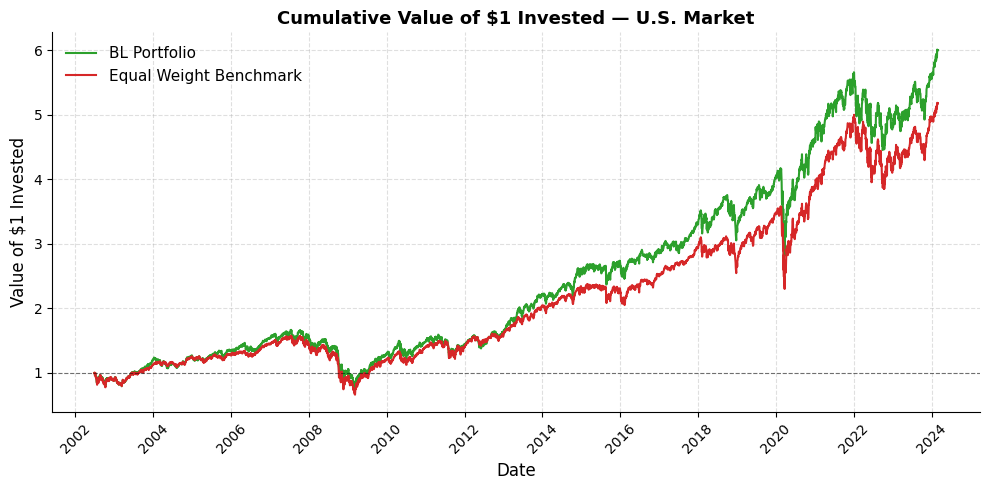

In [142]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(final_merged["Date"], money_norm, color="#2ca02c", linewidth=1.5, label="BL Portfolio")
ax.plot(final_merged["Date"], ew_norm,    color="#d62728", linewidth=1.5, label="Equal Weight Benchmark")

# Ligne de référence à 1
ax.axhline(y=1, color="black", linewidth=0.8, linestyle="--", alpha=0.5)

# Axes
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Value of \$1 Invested", fontsize=12)
ax.set_title("Cumulative Value of \$1 Invested — U.S. Market", fontsize=13, fontweight="bold")

# Format date sur l'axe x
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=45)

# Légende et grille
ax.legend(fontsize=11, frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)

# Style épuré
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figure1_cumulative_US.png", dpi=300, bbox_inches="tight")
plt.show()

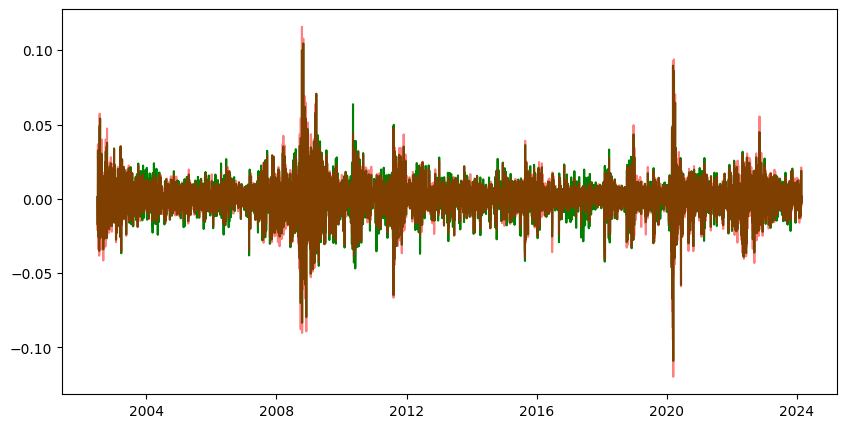

In [143]:
#MDD evolution
MDDdf=final[["Date","BENCH","Money"]]
MDDdf["BENCH Returns"]=(MDDdf["BENCH"].pct_change()).dropna()
MDDdf["Portfolio Returns"]=(MDDdf["Money"].pct_change()).dropna()
MDDdf.drop(columns=["BENCH","Money"],inplace=True)
MDDdf.dropna(inplace=True)

plt.figure(figsize=[10,5])
plt.plot(MDDdf["Date"],MDDdf["Portfolio Returns"],color="green")
plt.plot(MDDdf["Date"],MDDdf["BENCH Returns"],color="red",alpha=0.5)
plt.show()

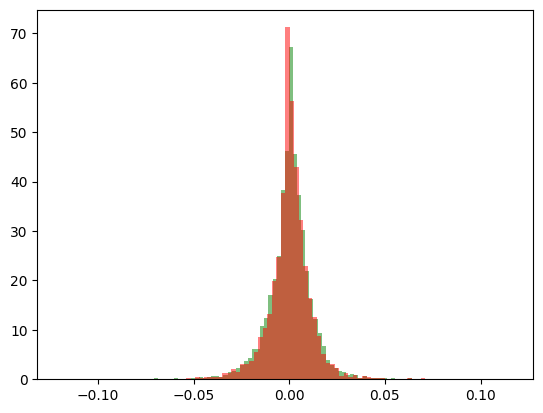

In [144]:
#Distribution of returns
plt.figure()
plt.hist(MDDdf["Portfolio Returns"], bins=100, density=True,alpha=0.5,color="green")
plt.hist(MDDdf["BENCH Returns"], bins=100, density=True,color="red",alpha=0.5)

muPF = MDDdf["Portfolio Returns"].mean()
sigmaPF = MDDdf["Portfolio Returns"].std()
muBENCH = MDDdf["BENCH Returns"].mean()
sigmaBENCH = MDDdf["BENCH Returns"].std()
plt.show()

In [145]:
#Maximum draw down
prices=final[["Date","Money","BENCH"]]
running_max_BENCH = prices["BENCH"].cummax()
drawdown_BENCH = prices["BENCH"] / running_max_BENCH- 1
running_max_PF=prices["Money"].cummax()
drawdown_PF = prices["Money"] / running_max_PF - 1
prices["drawdown_BENCH"]=drawdown_BENCH
prices["drawdown_PF"]=drawdown_PF

indexMDDBENCH=prices["drawdown_BENCH"].idxmin()
indexMDDPF= prices["drawdown_PF"].idxmin()

if indexMDDBENCH==indexMDDPF:
    print("Same MDD date")
    print("MDD : ",prices.iloc[indexMDDBENCH])
else :
    print("MDD BENCH : ",prices.iloc[indexMDDBENCH])
    print("MDD PF : ",prices.iloc[indexMDDPF])

Same MDD date
MDD :  Date              2009-03-09 00:00:00
Money                  7589740.603815
BENCH                          676.53
drawdown_BENCH              -0.567754
drawdown_PF                 -0.544327
Name: 1747, dtype: object


In [146]:
#average returns per year
AnnualizedDf=final[["Date","BENCH","Money"]]
AnnualizedDf['Date'] = pd.to_datetime(AnnualizedDf['Date'])
AnnualizedDf['Year'] = AnnualizedDf['Date'].dt.year

YearList=AnnualizedDf["Year"].unique()
BENCHAnnualized=pd.DataFrame(columns=YearList)
StratAnnualized=pd.DataFrame(columns=YearList)



for year in YearList:
  compteurPerYear=0
  for i in AnnualizedDf.index:
    if AnnualizedDf.loc[i,"Year"]==year:
      if compteurPerYear==0:
        BENCHAnnualized.loc[compteurPerYear,year]=AnnualizedDf.loc[i,"BENCH"]
        StratAnnualized.loc[compteurPerYear,year]=AnnualizedDf.loc[i,"Money"]
      else :
        BENCHAnnualized.loc[compteurPerYear,year]=AnnualizedDf.loc[i,"BENCH"]/BENCHAnnualized.loc[0,year]*100-100
        StratAnnualized.loc[compteurPerYear,year]=AnnualizedDf.loc[i,"Money"]/StratAnnualized.loc[0,year]*100-100
      compteurPerYear+=1

for year in YearList:
  BENCHAnnualized.loc[0,year]=BENCHAnnualized.loc[0,year]/BENCHAnnualized.loc[0,year]*100-100
  StratAnnualized.loc[0,year]=StratAnnualized.loc[0,year]/StratAnnualized.loc[0,year]*100-100



BENCHAvg=[]
StratAvg=[]
for i in BENCHAnnualized.index:
  sumBENCH=0
  sumStrat=0
  for year in BENCHAnnualized.columns:
    sumBENCH+=BENCHAnnualized.loc[i,year]
    sumStrat+=StratAnnualized.loc[i,year]
  BENCHAvg.append(sumBENCH/len(YearList))
  StratAvg.append(sumStrat/len(YearList))

BENCHAnnualized=BENCHAnnualized.drop(columns=[2002,2024]) #you can also add 2002 and drop any columns that have an nan value
StratAnnualized=StratAnnualized.drop(columns=[2002,2024])

BENCHAvg=[]
StratAVG=[]

for i in BENCHAnnualized.index:
  sumBENCH=0
  sumStrat=0
  for year in BENCHAnnualized.columns:
    sumBENCH+=BENCHAnnualized.loc[i,year]
    sumStrat+=StratAnnualized.loc[i,year]
  BENCHAvg.append(sumBENCH/len(YearList))
  StratAVG.append(sumStrat/len(YearList))

dff = pd.DataFrame({"Index": (range(len(BENCHAvg))),"Portfolio": StratAVG,"BENCH": BENCHAvg})


fig = px.line(dff, x="Index", y=["BENCH","Portfolio"], color_discrete_map={"BENCH": "red","Portfolio": "green"})
fig.show()



In [147]:
import pandas as pd
import numpy as np
import plotly.express as px

df2 = final[["Date", "BENCH", "Money"]].copy()
df2["Portfolio"] = df2["Money"]
df2.drop(columns="Money", inplace=True)
df2["Date"] = pd.to_datetime(df2["Date"], dayfirst=True)
df2.set_index("Date", inplace=True)

daily_returns = df2.pct_change()
daily_returns.dropna(inplace=True)

daily_returns["Volatility of the Benchmark"] = daily_returns['BENCH'].rolling(window=252).std() * np.sqrt(252)
daily_returns["Volatility of the Portfolio"] = daily_returns['Portfolio'].rolling(window=252).std() * np.sqrt(252)
data_to_plot = daily_returns.dropna()


fig = px.line(data_to_plot,
              x=data_to_plot.index,
              y=["Volatility of the Benchmark", "Volatility of the Portfolio"],
              labels={"value": "Volatility of the Benchmark", "variable": "Actif", "Date": "Date"},
              title="annualized vol : BENCH vs Portfolio")

fig.show()

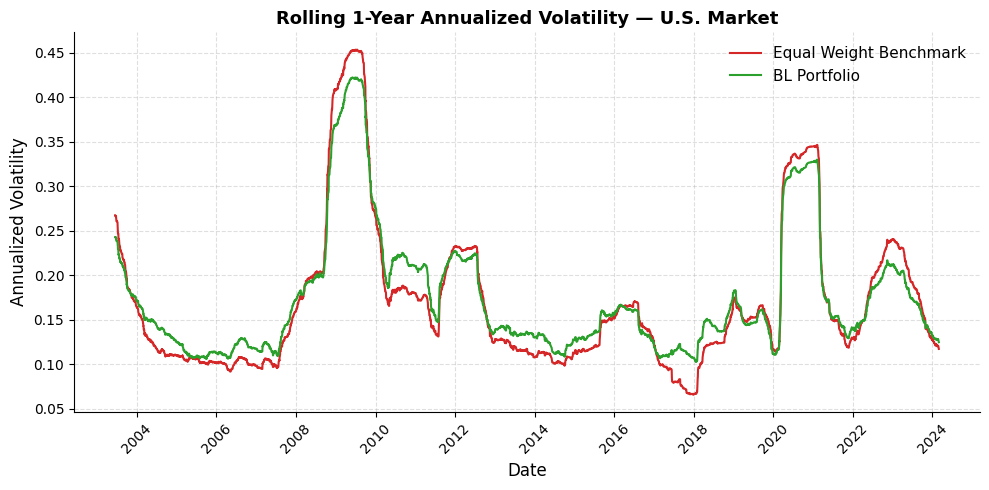

In [148]:
df2 = final[["Date", "BENCH", "Money"]].copy()
df2.rename(columns={"Money": "BL Portfolio"}, inplace=True)
df2["Date"] = pd.to_datetime(df2["Date"], dayfirst=True)
df2.set_index("Date", inplace=True)

daily_returns = df2.pct_change().dropna()
daily_returns["Vol Benchmark"]   = daily_returns["BENCH"].rolling(252).std() * np.sqrt(252)
daily_returns["Vol BL Portfolio"] = daily_returns["BL Portfolio"].rolling(252).std() * np.sqrt(252)
data_to_plot = daily_returns[["Vol Benchmark", "Vol BL Portfolio"]].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(data_to_plot.index, data_to_plot["Vol Benchmark"],   color="#d62728", linewidth=1.5, label="Equal Weight Benchmark")
ax.plot(data_to_plot.index, data_to_plot["Vol BL Portfolio"], color="#2ca02c", linewidth=1.5, label="BL Portfolio")

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Annualized Volatility", fontsize=12)
ax.set_title("Rolling 1-Year Annualized Volatility — U.S. Market", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
plt.xticks(rotation=45)
ax.legend(fontsize=11, frameon=False)
ax.grid(True, linestyle="--", alpha=0.4)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("figure_rolling_vol_US.png", dpi=300, bbox_inches="tight")
plt.show()

In [149]:
import numpy as np

#annualized vol and returns
final_merged["ret_portfolio"] = final_merged["Money"].pct_change()
final_merged["ret_ew"]        = final_merged["ew"].pct_change()
n_days = len(final_merged)
ann_ret_portfolio = (final_merged["Money"].iloc[-1] / final_merged["Money"].iloc[0]) ** (252 / n_days) - 1
ann_ret_ew        = (final_merged["ew"].iloc[-1]    / final_merged["ew"].iloc[0])    ** (252 / n_days) - 1
ann_vol_portfolio = final_merged["ret_portfolio"].std() * np.sqrt(252)
ann_vol_ew        = final_merged["ret_ew"].std()        * np.sqrt(252)

print(f"BL Portfolio  — Ann. Return: {ann_ret_portfolio:.2%}  |  Ann. Vol: {ann_vol_portfolio:.2%}")
print(f"Equal Weight  — Ann. Return: {ann_ret_ew:.2%}        |  Ann. Vol: {ann_vol_ew:.2%}")

BL Portfolio  — Ann. Return: 8.31%  |  Ann. Vol: 18.89%
Equal Weight  — Ann. Return: 7.60%        |  Ann. Vol: 19.09%


In [150]:
#compute VAR and ES at a fixed alpha
def calculate_historical_var_es(df, col_name='Money', confidence_level=0.95):
    returns = df[col_name].pct_change().dropna()
    cutoff = 1 - confidence_level
    var_value = returns.quantile(cutoff)
    worst_returns = returns[returns <= var_value]
    es_value = worst_returns.mean()
    return {"confidence_level": confidence_level,"VaR": -var_value,"ES": -es_value,"count_returns": len(returns),"count_breaches": len(worst_returns)}

#compute sharpe ratio
def calculate_sharpe_ratio(df, col_name='close', risk_free_rate_annual=0.04):
    returns = (df[col_name] - df[col_name].shift(1)) / df[col_name].shift(1)
    returns = returns.dropna()
    rf_daily = risk_free_rate_annual / 252
    excess_returns = returns - rf_daily
    sharpe_daily = excess_returns.mean() / excess_returns.std()
    sharpe_annualized = sharpe_daily * np.sqrt(252)
    return sharpe_annualized

In [151]:
print("Portfolio Risk Measures:")
print(calculate_historical_var_es(final, 'Money', 0.99))
print(f"Sharpe Ratio: {calculate_sharpe_ratio(final, 'Money', 0.03):.2f}")

print("\nBENCH Risk Measures:")
print(calculate_historical_var_es(final, 'BENCH', 0.99))
print(f"Sharpe Ratio: {calculate_sharpe_ratio(final, 'BENCH', 0.03):.2f}")

Portfolio Risk Measures:
{'confidence_level': 0.99, 'VaR': 0.03331629922177542, 'ES': 0.04690628446860213, 'count_returns': 5655, 'count_breaches': 57}
Sharpe Ratio: 0.36

BENCH Risk Measures:
{'confidence_level': 0.99, 'VaR': 0.03434913118664733, 'ES': 0.04992406705908623, 'count_returns': 5655, 'count_breaches': 57}
Sharpe Ratio: 0.32


In [152]:
#weekly var and es
def weekly(df, col_name='Money', confidence_level=0.99):
    df_weekly = df.set_index('Date')[col_name].resample('W').last().dropna()
    returns = df_weekly.pct_change().dropna()
    cutoff = 1 - confidence_level
    var_value = returns.quantile(cutoff)
    worst_returns = returns[returns <= var_value]
    es_value = worst_returns.mean()
    return {"confidence_level": confidence_level,"VaR": -var_value,"ES": -es_value,"count_returns": len(returns),"count_breaches": len(worst_returns)}

var_weekly_pf    = weekly(final, col_name='Money',  confidence_level=0.99)
var_weekly_bench = weekly(final, col_name='BENCH', confidence_level=0.99)

print("Portfolio Weekly VaR 99%:", var_weekly_pf)
print("Benchmark Weekly VaR 99%:", var_weekly_bench)

Portfolio Weekly VaR 99%: {'confidence_level': 0.99, 'VaR': 0.06642973618610587, 'ES': 0.09265118539625934, 'count_returns': 1131, 'count_breaches': 12}
Benchmark Weekly VaR 99%: {'confidence_level': 0.99, 'VaR': 0.06821658474653486, 'ES': 0.09516708473268239, 'count_returns': 1131, 'count_breaches': 12}


**BELOW ARE UN-USED FUNCTIONS, FEEL FREE TO ADD THEM TO OUR TESTING**

In [153]:
#compute the lambda value using the mean return, risk free rate and variance of the portfolio

holderlambda=[]
holderdate=[]
def GetLambda(df,date,timeofcalculation,RfDf):
    returns=GetReturn(df,date,timeofcalculation) #daily returns
    weight_vector=GetWeight(df,date=0)

    mean_return=np.mean(np.dot(returns,weight_vector))
    mean_annual=(1+mean_return)**252-1 #annualized mean return


    rf_temps=GetRiskFree(df,date,timeofcalculation,RfDf)
    rf_annual=(1+rf_temps)**(252/timeofcalculation)-1 #annualized risk free rate


    Sigma=get_shrunk_covariance(df,date,timeofcalculation)
    Sigma_annual=252*Sigma #annualized covariance matrix
    var = float((weight_vector.T @ Sigma_annual.values @ weight_vector).item())
    lambda_value=(mean_annual - rf_annual)/var


    excess = mean_annual - rf_annual
    sigma2 = var
    sigma  = np.sqrt(var)
    #print("Excess:", excess, " Var:", sigma2, " Vol:", sigma, " λ:", lam, " Sharpe:", sharpe)
    holderdate.append(date)
    holderlambda.append(lambda_value)
    return lambda_value


In [154]:
def ComputeRiskyCoefficient(a):
    dfQTY=a.copy()
    dfQTY.dropna(inplace=True)
    variablelen=252*3
    dfQTY=dfQTY.iloc[dfQTY.shape[0]-variablelen::1]

    returnsLONG = dfQTY["Money"].pct_change().dropna()
    returnsSPXLONG = dfQTY["SPX"].pct_change().dropna()


    dailyvolSPXLONG=ewma_vol(returnsSPXLONG,  lam=0.96)
    dailyvolPFLONG=returnsLONG.std()

    shorttime=63
    dfQTY=dfQTY.iloc[dfQTY.shape[0]-shorttime::1]

    returnsSHORT = dfQTY["Money"].pct_change().dropna()
    returnsSPXSHORT = dfQTY["SPX"].pct_change().dropna()

    dailyvolSPXSHORT=ewma_vol(returnsSPXSHORT, lam=0.94)
    dailyvolPFSHORT=returnsSHORT.std()


    taubase=0.05

    current_tau=taubase
    current_tau=np.clip(current_tau,0.005,0.1)


    return current_tau

#ComputeRiskyCoefficient(final)